# Modélisation — Comparaison Multi-Modèles
## Projet : Optimisation du ROI Marketing

**Modèles entraînés :**
1. Régression Linéaire (baseline)
2. Random Forest
3. XGBoost (Gradient Boosting)
4. MLP (réseau de neurones)

**Métriques :** MAE, RMSE, R², Cross-Validation

## 0. Imports

In [2]:
import sys, os
sys.path.append('..')
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from src.models.train import (
    train_all_models, get_models,
    train_and_evaluate, _build_summary
)
from src.preprocessing.pipeline import load_and_prepare_data

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print(' Imports OK')

 Imports OK


## 1. Entraînement de tous les modèles

In [3]:
results, trained_models, feature_names, X_test, y_test = train_all_models(
    data_path='../data/marketing_and_sales.csv'
)
print('\n Tous les modèles entraînés et sauvegardés.')

Chargement et nettoyage...
  [nettoyage] 6 ligne(s) supprimée(s) (Sales manquant)
  [nettoyage] Dataset final : 4566 lignes × 5 colonnes
  [split] Train : 3652 | Test : 914
Fitting du preprocessor sur le train set...
  [features] 7 features finales : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']
Preprocessing terminé.
Preprocessor sauvegardé → c:\Users\Matthys\Desktop\dossier python\marketing-roi-optimizer\notebooks\..\src\preprocessing\..\..\models\preprocessor.pkl

 Entraînement : LinearRegression...
  Test  — MAE: 2.5858 | RMSE: 5.8793 | R²: 0.9960
  CV R² — 0.9950 ± 0.0026
  Modèle sauvegardé → c:\Users\Matthys\Desktop\dossier python\marketing-roi-optimizer\notebooks\..\src\models\..\..\models\LinearRegression.pkl

 Entraînement : RandomForest...
  Test  — MAE: 2.7340 | RMSE: 3.8391 | R²: 0.9983
  CV R² — 0.9964 ± 0.0021
  Modèle sauvegardé → c:\Users\Matthys\Desktop\dossier python\marketing-roi-optimizer\notebooks\..\src\models\..\..\models\RandomForest.pkl

 E

## 2. Tableau comparatif des performances

In [4]:
summary = _build_summary(results)
print('=== COMPARAISON DES MODÈLES ===')
display(summary.style
    .highlight_max(subset=['R² Test', 'CV R² (mean)'], color='lightgreen')
    .highlight_min(subset=['MAE Test', 'RMSE Test', 'CV R² (std)'], color='lightgreen')
    .format(precision=4)
)

=== COMPARAISON DES MODÈLES ===


,Modèle,MAE Test,RMSE Test,R² Test,CV R² (mean),CV R² (std)
0,RandomForest,2.7340,3.8391,0.9983,0.9964,0.0021
1,XGBoost,3.0353,4.4638,0.9977,0.9956,0.0015
2,LinearRegression,2.5858,5.8793,0.9960,0.9950,0.0026
3,MLP,3.3596,6.4914,0.9951,0.9943,0.0023


## 3. Visualisation des métriques

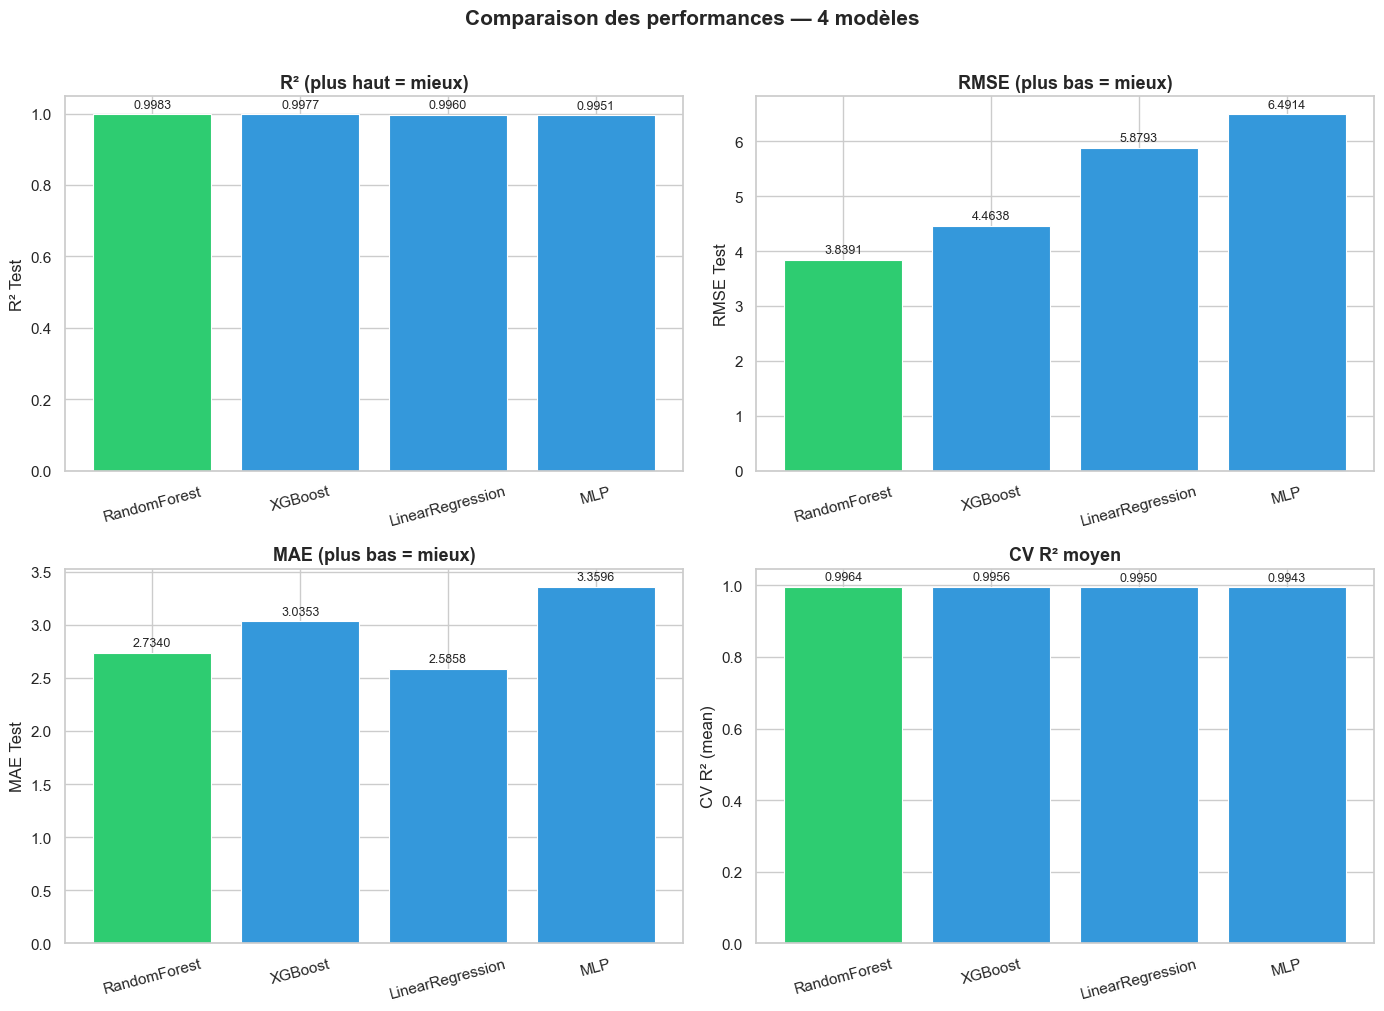

In [5]:
model_names = summary['Modèle'].tolist()
metrics_to_plot = [
    ('R² Test',      'R² (plus haut = mieux)',  True),
    ('RMSE Test',    'RMSE (plus bas = mieux)',  False),
    ('MAE Test',     'MAE (plus bas = mieux)',   False),
    ('CV R² (mean)', 'CV R² moyen',              True),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(model_names))]

for idx, (metric, label, higher_better) in enumerate(metrics_to_plot):
    values = summary[metric].tolist()
    bars = axes[idx].bar(model_names, values, color=colors, edgecolor='white', linewidth=0.8)
    axes[idx].set_title(label, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=15)

    # Valeurs sur les barres
    for bar, val in zip(bars, values):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Comparaison des performances — 4 modèles', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Prédictions vs Valeurs réelles

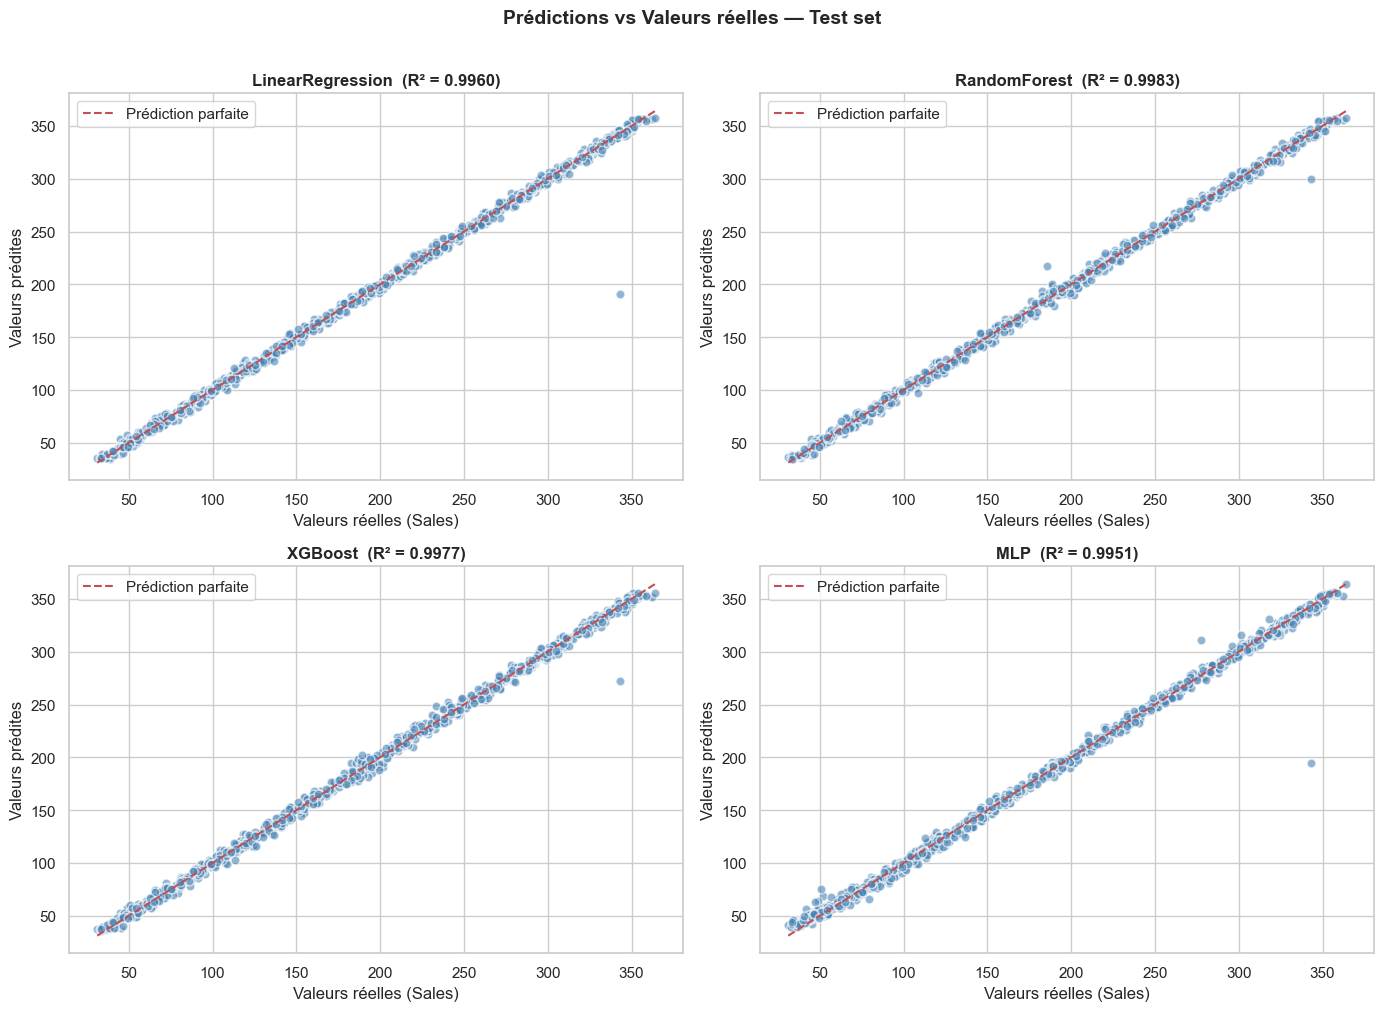

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = np.array(results[name]['y_pred_test'])
    r2     = results[name]['test']['R2']

    axes[idx].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=40)

    # Ligne parfaite
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[idx].plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')

    axes[idx].set_title(f'{name}  (R² = {r2:.4f})', fontweight='bold')
    axes[idx].set_xlabel('Valeurs réelles (Sales)')
    axes[idx].set_ylabel('Valeurs prédites')
    axes[idx].legend()

plt.suptitle('Prédictions vs Valeurs réelles — Test set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/predictions_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse des résidus

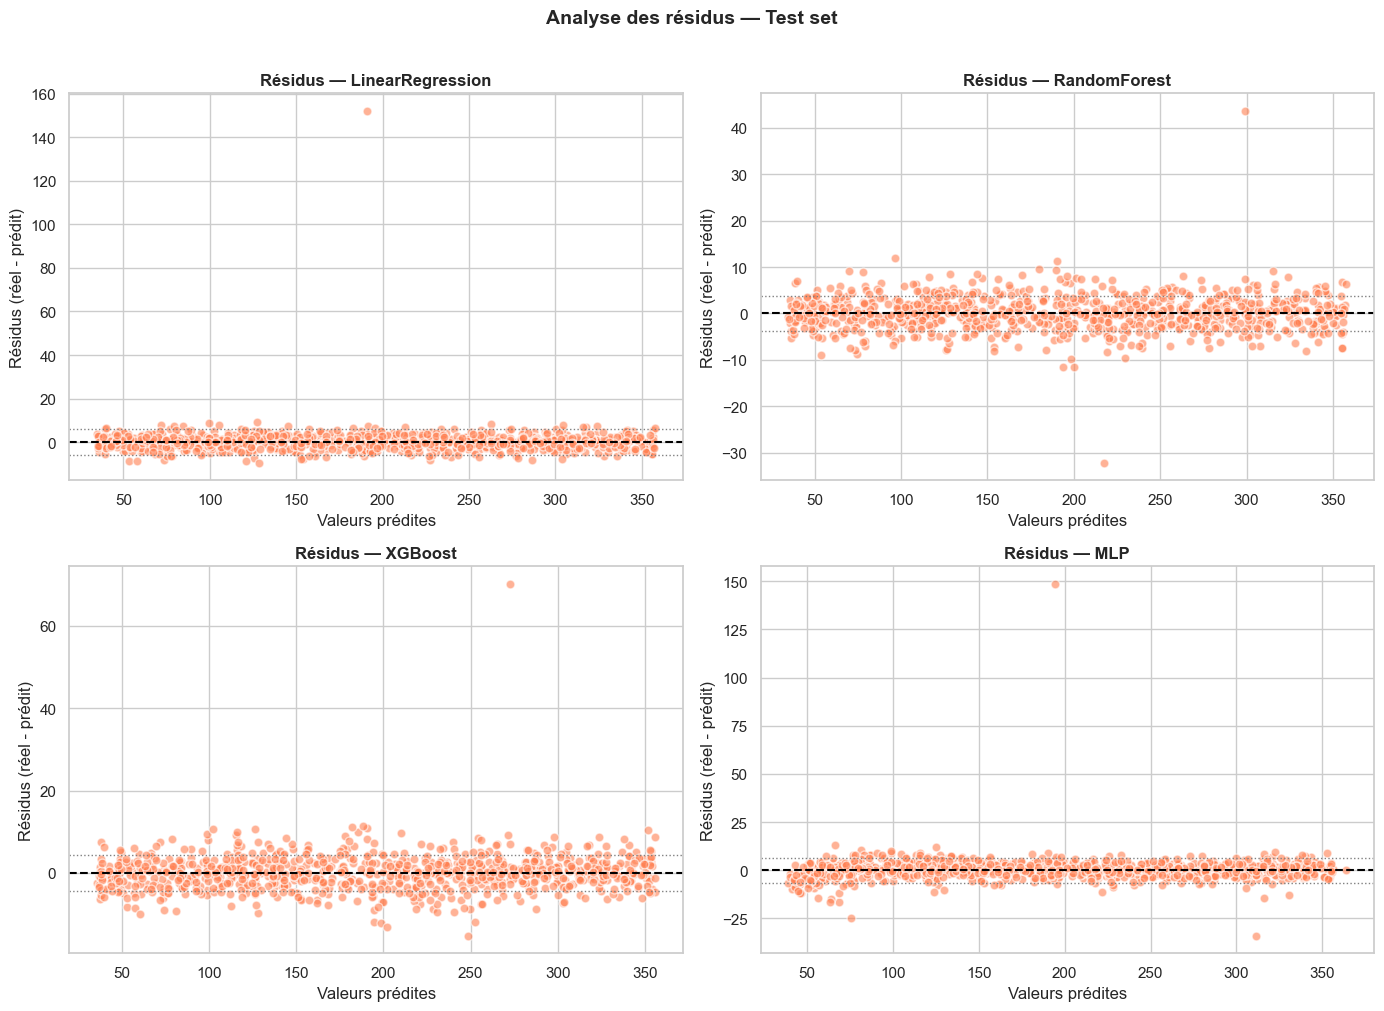

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, name in enumerate(trained_models.keys()):
    y_pred   = np.array(results[name]['y_pred_test'])
    residuals = y_test - y_pred

    axes[idx].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', s=40)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'Résidus — {name}', fontweight='bold')
    axes[idx].set_xlabel('Valeurs prédites')
    axes[idx].set_ylabel('Résidus (réel - prédit)')

    # Zone ±1 std
    std_res = residuals.std()
    axes[idx].axhline(y= std_res, color='gray', linestyle=':', linewidth=1)
    axes[idx].axhline(y=-std_res, color='gray', linestyle=':', linewidth=1)

plt.suptitle('Analyse des résidus — Test set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/residuals_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance — Random Forest & XGBoost

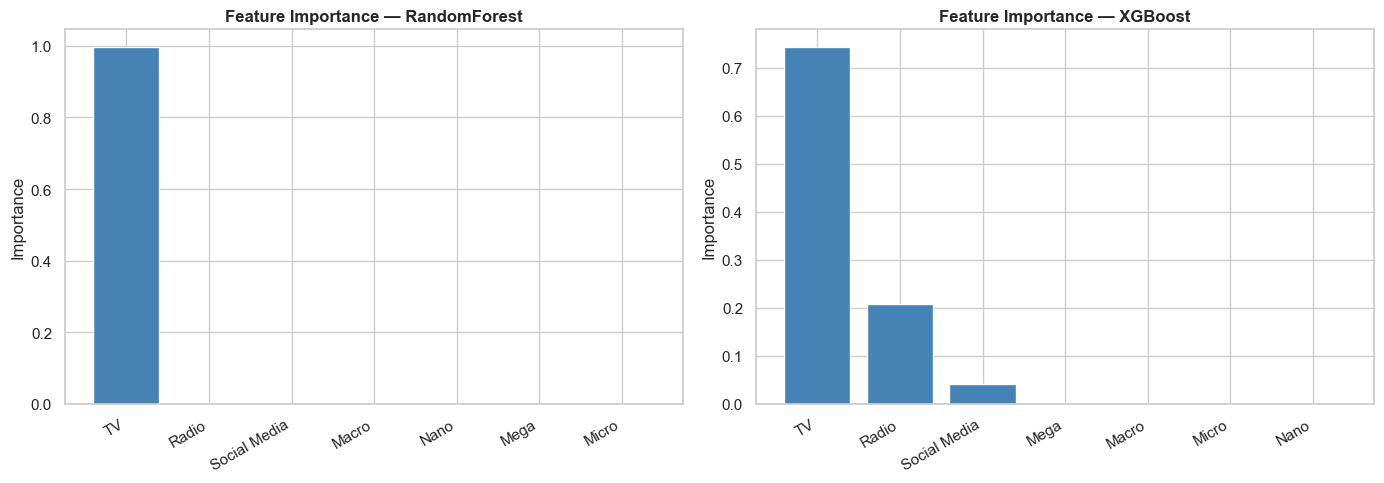

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, name in enumerate(['RandomForest', 'XGBoost']):
    model      = trained_models[name]
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1]

    axes[idx].bar(
        range(len(feature_names)),
        importances[indices],
        color='steelblue', edgecolor='white'
    )
    axes[idx].set_xticks(range(len(feature_names)))
    axes[idx].set_xticklabels(
        [feature_names[i] for i in indices],
        rotation=30, ha='right'
    )
    axes[idx].set_title(f'Feature Importance — {name}', fontweight='bold')
    axes[idx].set_ylabel('Importance')

plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Synthèse — Choix du modèle final

In [9]:
best_name = summary.loc[summary['R² Test'].idxmax(), 'Modèle']
best_res  = results[best_name]

print(f"""
╔══════════════════════════════════════════════════════════╗
║           SYNTHÈSE — CHOIX DU MODÈLE FINAL               ║
╠══════════════════════════════════════════════════════════╣

Meilleur modèle (R² Test) : {best_name}

   MAE  Test : {best_res['test']['MAE']}
   RMSE Test : {best_res['test']['RMSE']}
   R²   Test : {best_res['test']['R2']}
   CV R²     : {best_res['cv_r2_mean']} ± {best_res['cv_r2_std']}

""")


╔══════════════════════════════════════════════════════════╗
║           SYNTHÈSE — CHOIX DU MODÈLE FINAL               ║
╠══════════════════════════════════════════════════════════╣

Meilleur modèle (R² Test) : RandomForest

   MAE  Test : 2.734
   RMSE Test : 3.8391
   R²   Test : 0.9983
   CV R²     : 0.9964 ± 0.0021


